## Frame

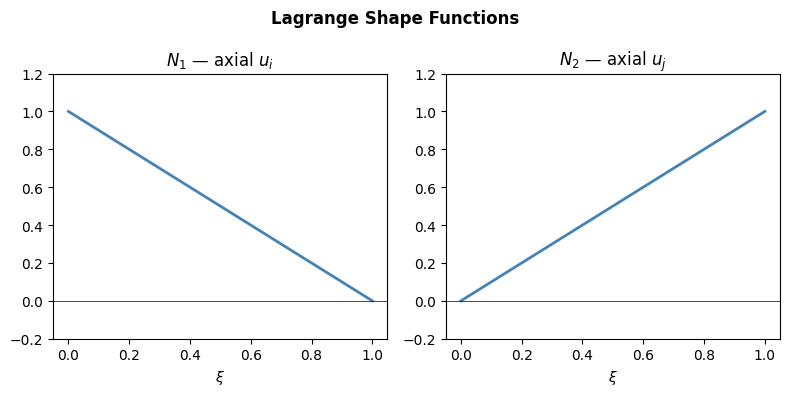

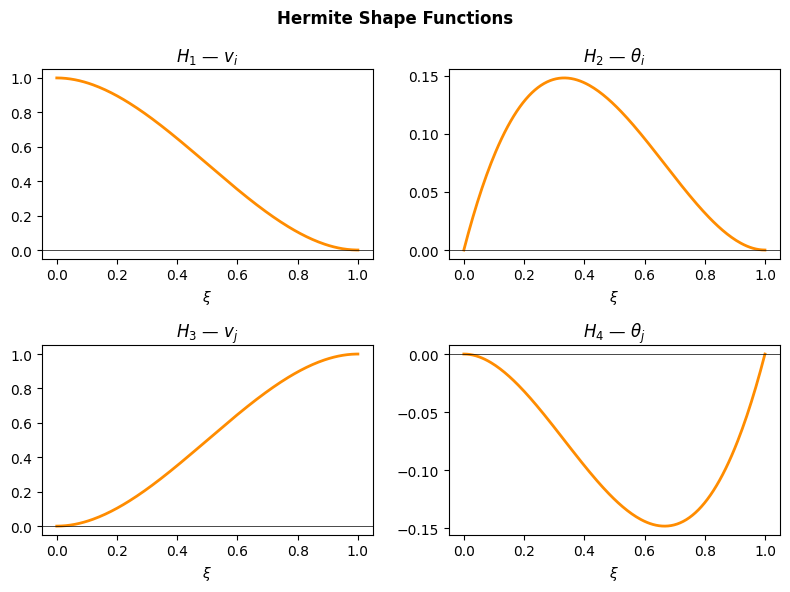

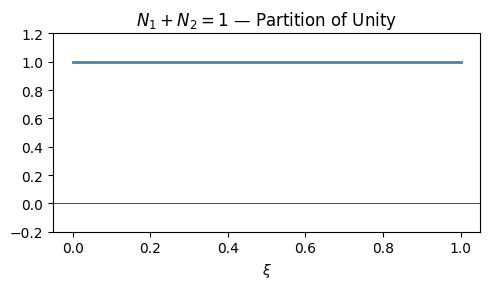

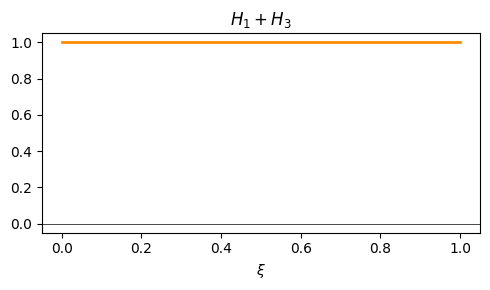

In [1]:
import numpy as np
import matplotlib.pyplot as plt

L  = 1.0
xi = np.linspace(0, 1, 200)

# Lagrange
N1 = 1 - xi
N2 = xi

# Hermite
H1 =  1 - 3*xi**2 + 2*xi**3
H2 =  L*(xi - 2*xi**2 + xi**3)
H3 =  3*xi**2 - 2*xi**3
H4 =  L*(-xi**2 + xi**3)

# --- Lagrange ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].plot(xi, N1, color='steelblue', lw=2)
axes[0].set_title('$N_1$ — axial $u_i$')
axes[0].set_xlabel('$\\xi$')
axes[1].plot(xi, N2, color='steelblue', lw=2)
axes[1].set_title('$N_2$ — axial $u_j$')
axes[1].set_xlabel('$\\xi$')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylim(-0.2, 1.2)
fig.suptitle('Lagrange Shape Functions', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Hermite ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
hermite = [H1, H2, H3, H4]
titles  = ['$H_1$ — $v_i$', '$H_2$ — $\\theta_i$',
           '$H_3$ — $v_j$', '$H_4$ — $\\theta_j$']
for i, ax in enumerate(axes.flat):
    ax.plot(xi, hermite[i], color='darkorange', lw=2)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(titles[i])
    ax.set_xlabel('$\\xi$')
fig.suptitle('Hermite Shape Functions', fontweight='bold')
plt.tight_layout()
plt.show()


# --- Sum of Lagrange ---
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xi, N1 + N2, color='steelblue', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylim(-0.2, 1.2)
ax.set_title('$N_1 + N_2 = 1$ — Partition of Unity')
ax.set_xlabel('$\\xi$')
plt.tight_layout()
plt.show()

# --- Sum of Hermite ---
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xi, H1 + H3, color='darkorange', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('$H_1 + H_3$')
ax.set_xlabel('$\\xi$')
plt.tight_layout()
plt.show()

# # --- Sum of Hermite ---
# fig, ax = plt.subplots(figsize=(5, 3))
# ax.plot(xi, H2 + H4, color='darkorange', lw=2)
# ax.axhline(0, color='k', lw=0.5)
# ax.set_title('$H_1 + H_2 + H_3 + H_4$')
# ax.set_xlabel('$\\xi$')
# plt.tight_layout()
# plt.show()

## CST

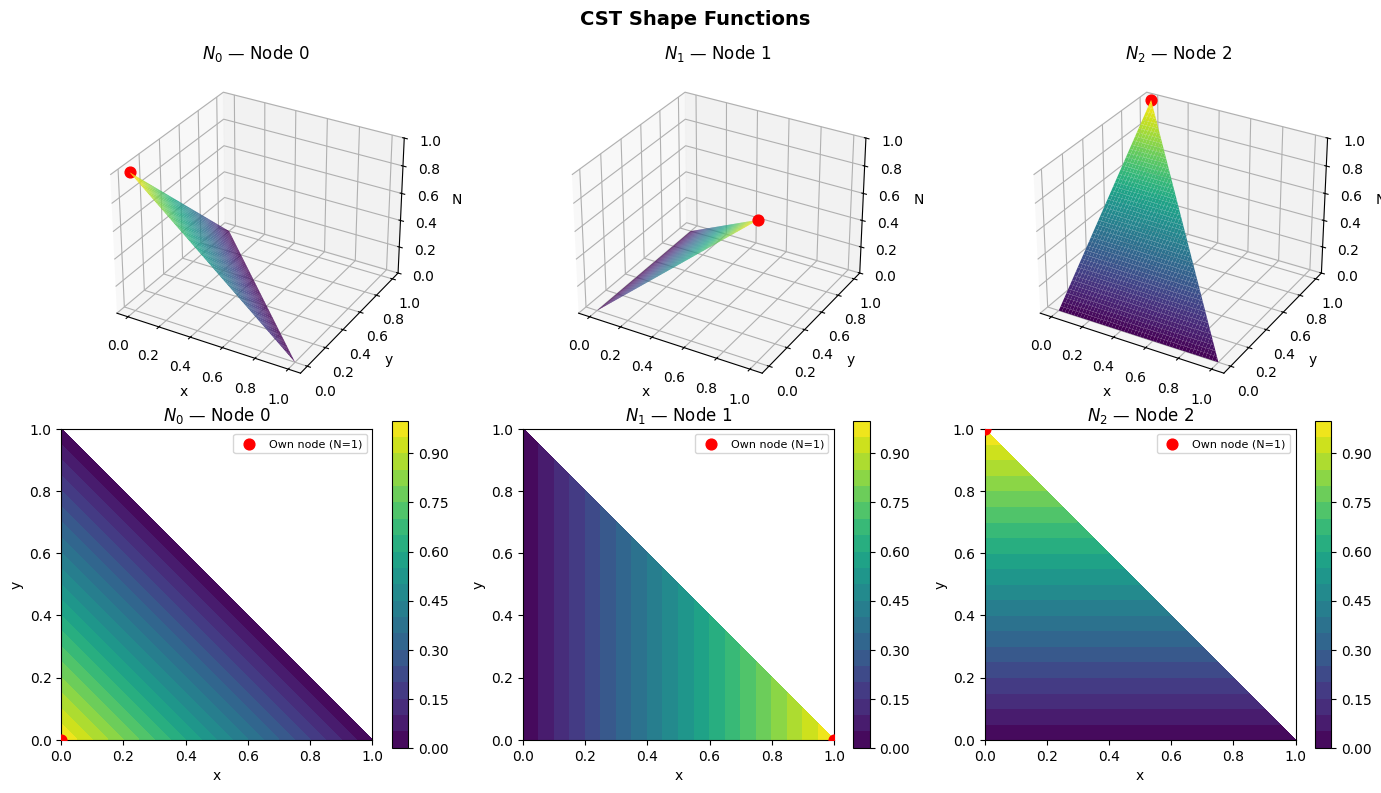

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates (counter-clockwise)
x0, y0 = 0.0, 0.0
x1, y1 = 1.0, 0.0
x2, y2 = 0.0, 1.0

# Grid in natural coordinates
n = 500
xi  = np.linspace(0, 1, n)
eta = np.linspace(0, 1, n)
XI, ETA = np.meshgrid(xi, eta)

# Mask: only points inside the triangle
mask = (XI + ETA <= 1)

# Cartesian coordinates of the grid
X = x0 + (x1-x0)*XI + (x2-x0)*ETA
Y = y0 + (y1-y0)*XI + (y2-y0)*ETA

# CST shape functions: N_i = xi_i
N0 = np.where(mask, 1 - XI - ETA, np.nan)  # node 0
N1 = np.where(mask, XI,            np.nan)  # node 1
N2 = np.where(mask, ETA,           np.nan)  # node 2

shapes = [N0, N1, N2]
labels = ['$N_0$ — Node 0', '$N_1$ — Node 1', '$N_2$ — Node 2']
nodes  = [(x0, y0), (x1, y1), (x2, y2)]

fig = plt.figure(figsize=(14, 8))

for i in range(3):
    # 3D view
    ax3d = fig.add_subplot(2, 3, i+1, projection='3d')
    ax3d.plot_surface(X, Y, shapes[i], cmap='viridis')
    ax3d.scatter(*nodes[i], 1.0, color='red', s=60, zorder=5)
    ax3d.set_title(labels[i])
    ax3d.set_xlabel('x')
    ax3d.set_ylabel('y')
    ax3d.set_zlabel('N')
    ax3d.set_zlim(0, 1)

    # Plan view
    ax2d = fig.add_subplot(2, 3, i+4)
    cp = ax2d.contourf(X, Y, shapes[i], levels=20, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(cp, ax=ax2d)
    ax2d.scatter(*nodes[i], color='red', s=60, zorder=5, label='Own node (N=1)')
    ax2d.set_title(labels[i])
    ax2d.set_xlabel('x')
    ax2d.set_ylabel('y')
    ax2d.set_aspect('equal')
    ax2d.legend(fontsize=8)

fig.suptitle('CST Shape Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## QUAD4

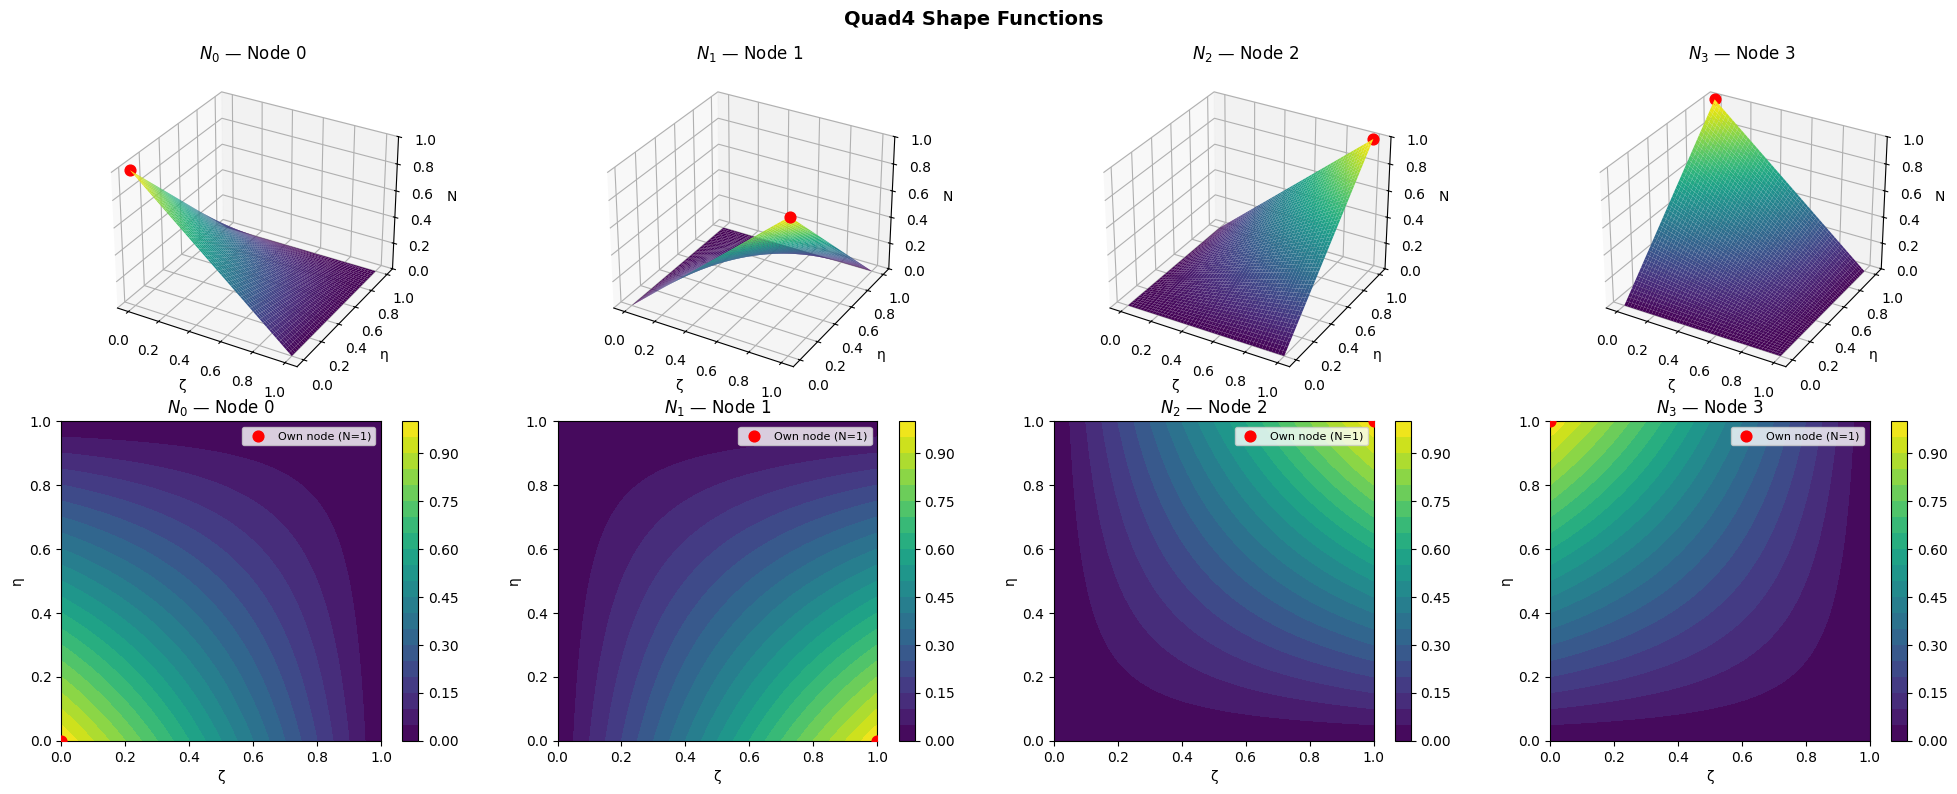

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates (counter-clockwise)
x0, y0 = -1.0, -1.0
x1, y1 =  1.0, -1.0
x2, y2 =  1.0,  1.0
x3, y3 = -1.0,  1.0

# Grid in natural coordinates (ζ, η)
n = 400
zeta = np.linspace(-1, 1, n)
eta  = np.linspace(-1, 1, n)
Z, E = np.meshgrid(zeta, eta)

# Cartesian coordinates of the grid (unit square for display)
X = 0.5 * (Z + 1)
Y = 0.5 * (E + 1)

# Quad4 shape functions: N_i = (1 ± ζ)(1 ± η) / 4
N0 = (1 - Z) * (1 - E) / 4    # node 0
N1 = (1 + Z) * (1 - E) / 4    # node 1
N2 = (1 + Z) * (1 + E) / 4    # node 2
N3 = (1 - Z) * (1 + E) / 4    # node 3

shapes = [N0, N1, N2, N3]
labels = ['$N_0$ — Node 0', '$N_1$ — Node 1', '$N_2$ — Node 2', '$N_3$ — Node 3']
nodes  = [(0, 0), (1, 0), (1, 1), (0, 1)]

fig = plt.figure(figsize=(20, 8))
for i in range(4):
    # 3D view
    ax3d = fig.add_subplot(2, 4, i + 1, projection='3d')
    ax3d.plot_surface(X, Y, shapes[i], cmap='viridis')
    ax3d.scatter(*nodes[i], 1.0, color='red', s=60, zorder=5)
    ax3d.set_title(labels[i])
    ax3d.set_xlabel('ζ')
    ax3d.set_ylabel('η')
    ax3d.set_zlabel('N')
    ax3d.set_zlim(0, 1)
    # Plan view
    ax2d = fig.add_subplot(2, 4, i + 5)
    cp = ax2d.contourf(X, Y, shapes[i], levels=20, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(cp, ax=ax2d)
    ax2d.scatter(*nodes[i], color='red', s=60, zorder=5, label='Own node (N=1)')
    ax2d.set_title(labels[i])
    ax2d.set_xlabel('ζ')
    ax2d.set_ylabel('η')
    ax2d.set_aspect('equal')
    ax2d.legend(fontsize=8)

fig.suptitle('Quad4 Shape Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


fig.suptitle('LST Shape Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## LST

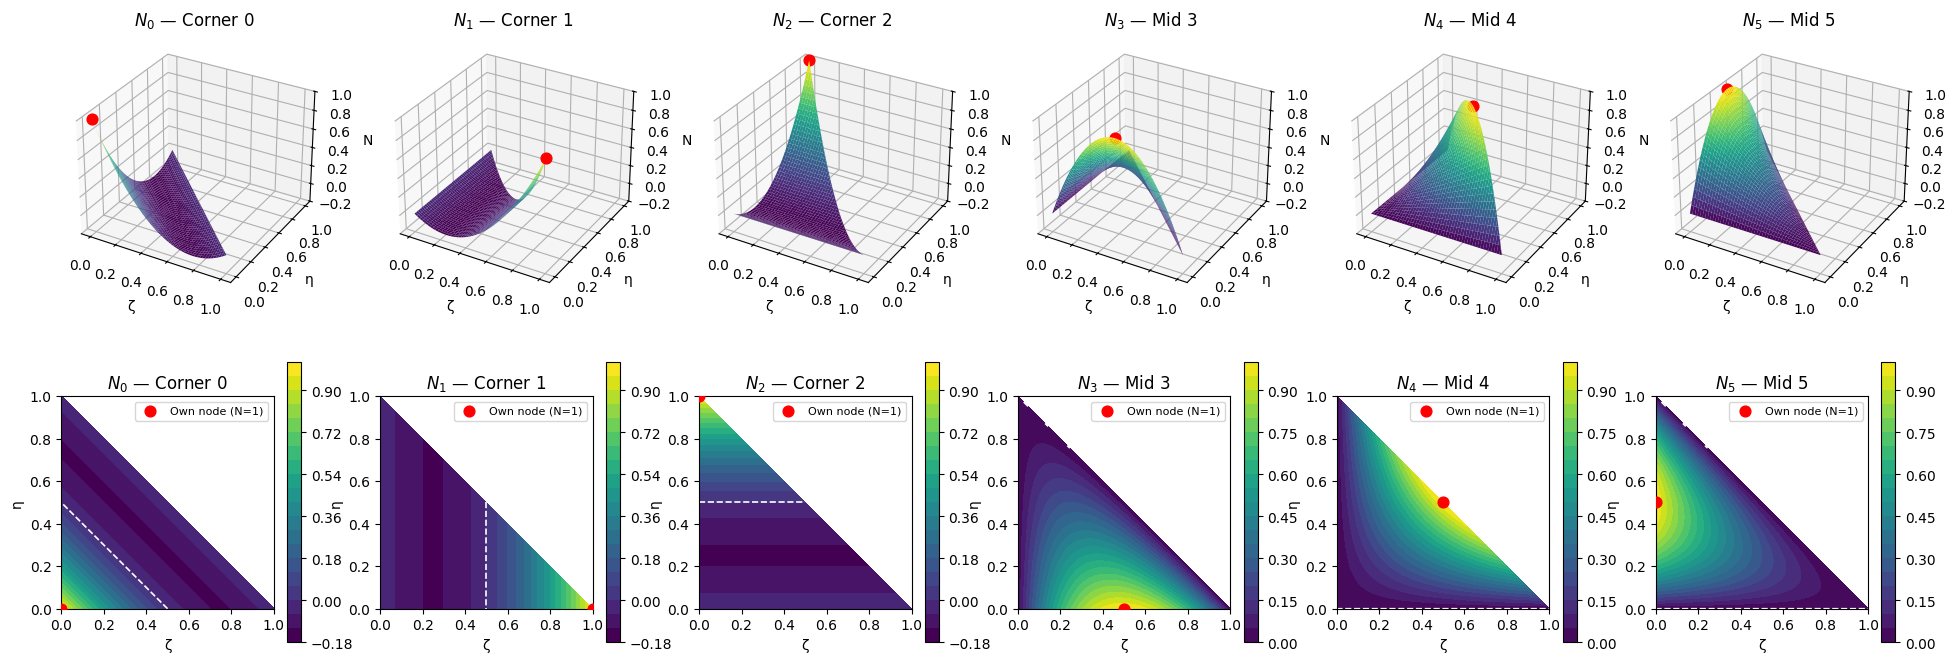

In [4]:

# Node coordinates (counter-clockwise)

z0, e0 = 0.0, 0.0
z1, e1 = 1.0, 0.0
z2, e2 = 0.0, 1.0
z3, e3 = 0.5, 0.0
z4, e4 = 0.5, 0.5
z5, e5 = 0.0, 0.5

# Grid in natural coordinates (ζ, η)
n = 500
zeta = np.linspace(0, 1, n)
eta  = np.linspace(0, 1, n)
Z, E = np.meshgrid(zeta, eta)

# Mask: only points inside the reference triangle
mask = (Z + E <= 1)

# Cartesian coordinates of the grid
X = np.where(mask, Z, np.nan)
Y = np.where(mask, E, np.nan)

# LST shape functions in (ζ, η):  ξ0=1-ζ-η,  ξ1=ζ,  ξ2=η
N0 = np.where(mask, (1-Z-E) * (1 - 2*Z - 2*E), np.nan)    # corner 0
N1 = np.where(mask, Z * (2*Z - 1),              np.nan)    # corner 1
N2 = np.where(mask, E * (2*E - 1),              np.nan)    # corner 2
N3 = np.where(mask, 4 * (1-Z-E) * Z,            np.nan)    # mid 0-1
N4 = np.where(mask, 4 * Z * E,                  np.nan)    # mid 1-2
N5 = np.where(mask, 4 * E * (1-Z-E),            np.nan)    # mid 2-0

shapes = [N0, N1, N2, N3, N4, N5]
labels = ['$N_0$ — Corner 0', '$N_1$ — Corner 1', '$N_2$ — Corner 2',
          '$N_3$ — Mid 3',    '$N_4$ — Mid 4',    '$N_5$ — Mid 5']
nodes  = [(z0,e0), (z1,e1), (z2,e2), (z3,e3), (z4,e4), (z5,e5)]

fig = plt.figure(figsize=(24, 8))
for i in range(6):
    # 3D view
    ax3d = fig.add_subplot(2, 6, i + 1, projection='3d')
    ax3d.plot_surface(X, Y, shapes[i], cmap='viridis')
    ax3d.scatter(*nodes[i], 1.0, color='red', s=60, zorder=5)
    ax3d.set_title(labels[i])
    ax3d.set_xlabel('ζ')
    ax3d.set_ylabel('η')
    ax3d.set_zlabel('N')
    ax3d.set_zlim(-0.2, 1)
    # Plan view
    ax2d = fig.add_subplot(2, 6, i + 7)
    vmin = -0.15 if i < 3 else 0.0
    cp = ax2d.contourf(X, Y, shapes[i], levels=20, cmap='viridis', vmin=vmin, vmax=1)
    plt.colorbar(cp, ax=ax2d)
    ax2d.contour(X, Y, shapes[i], levels=[0], colors='white',
                 linewidths=1.2, linestyles='--')
    ax2d.scatter(*nodes[i], color='red', s=60, zorder=5, label='Own node (N=1)')
    ax2d.set_title(labels[i])
    ax2d.set_xlabel('ζ')
    ax2d.set_ylabel('η')
    ax2d.set_aspect('equal')
    ax2d.legend(fontsize=8)
    ax2d.set_xlim(0, 1)
    ax2d.set_ylim(0, 1)

## QUAD9

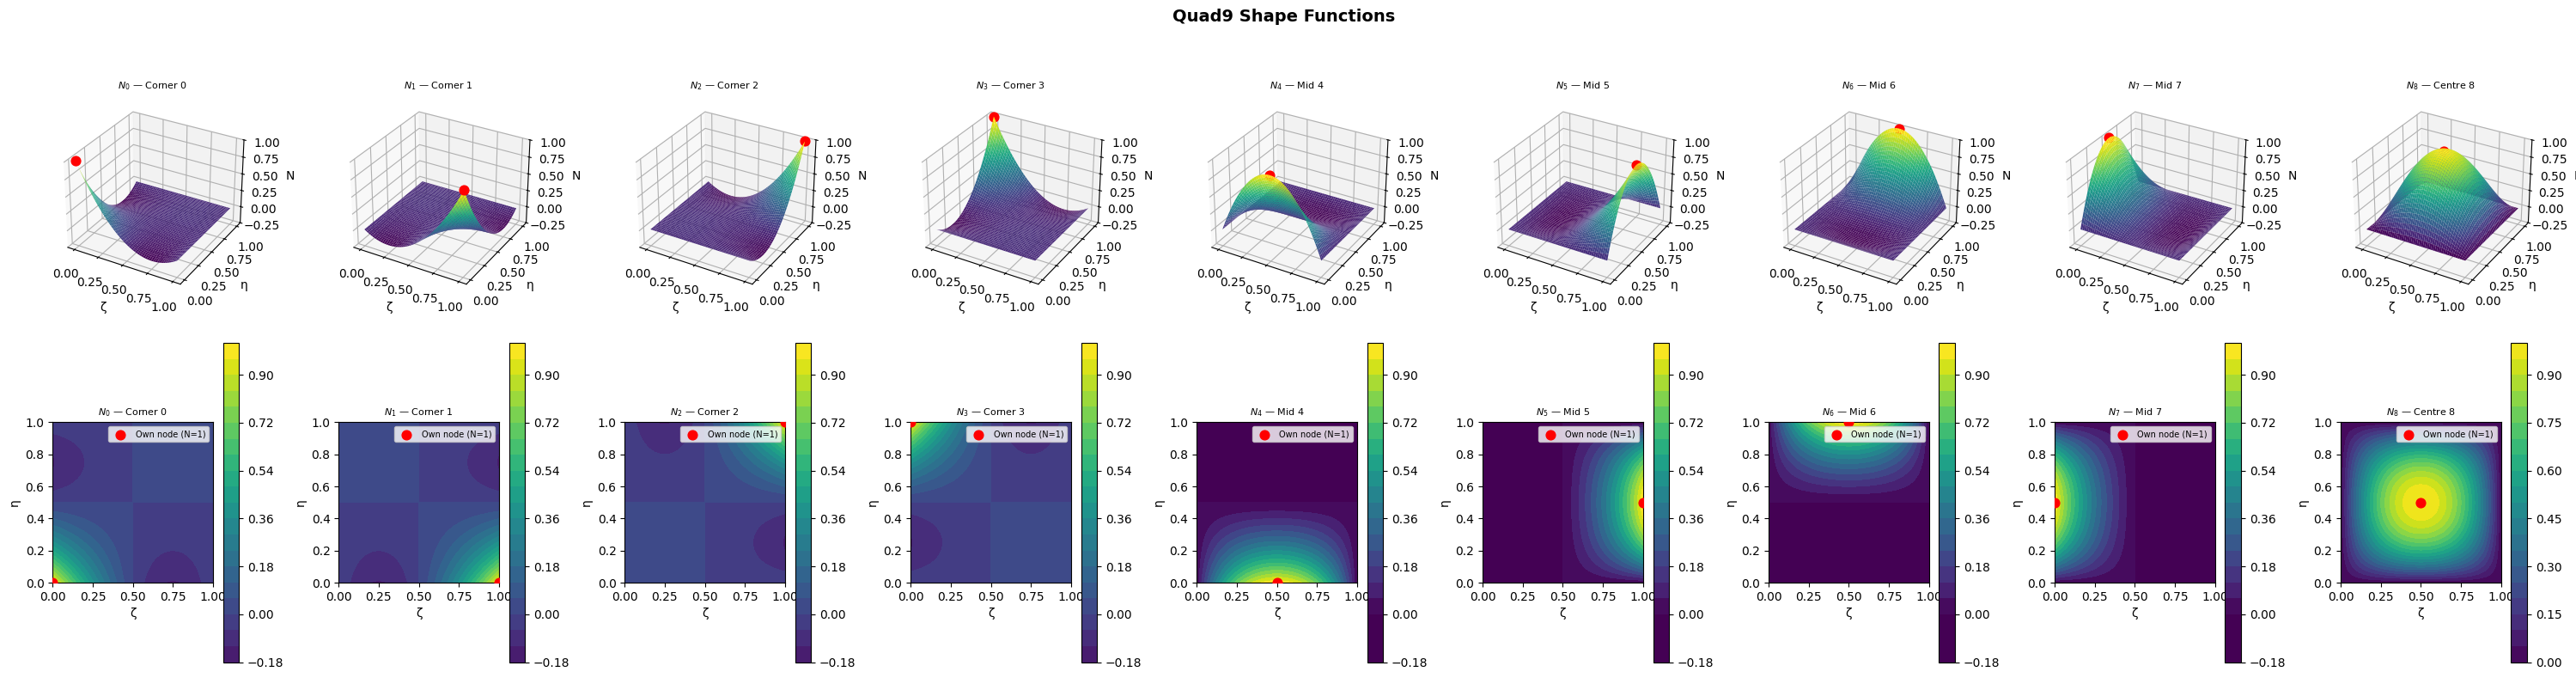

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates in natural space (ζ, η)

# Grid in natural coordinates (ζ, η)
n = 400
zeta = np.linspace(-1, 1, n)
eta  = np.linspace(-1, 1, n)
Z, E = np.meshgrid(zeta, eta)

# Cartesian coordinates of the grid (unit square for display)
X = 0.5 * (Z + 1)
Y = 0.5 * (E + 1)

# Quad9 shape functions — Lagrangian biquadratic
N0 = 0.25 * Z * (Z - 1) * E * (E - 1)     # corner 0  (-1,-1)
N1 = 0.25 * Z * (Z + 1) * E * (E - 1)     # corner 1  (+1,-1)
N2 = 0.25 * Z * (Z + 1) * E * (E + 1)     # corner 2  (+1,+1)
N3 = 0.25 * Z * (Z - 1) * E * (E + 1)     # corner 3  (-1,+1)
N4 = 0.50 * (1 - Z**2)  * E * (E - 1)     # mid-side 4  ( 0,-1)
N5 = 0.50 * Z * (Z + 1) * (1 - E**2)      # mid-side 5  (+1, 0)
N6 = 0.50 * (1 - Z**2)  * E * (E + 1)     # mid-side 6  ( 0,+1)
N7 = 0.50 * Z * (Z - 1) * (1 - E**2)      # mid-side 7  (-1, 0)
N8 = (1 - Z**2) * (1 - E**2)              # centre   8  ( 0, 0)

shapes = [N0, N1, N2, N3, N4, N5, N6, N7, N8]
labels = ['$N_0$ — Corner 0', '$N_1$ — Corner 1',
          '$N_2$ — Corner 2', '$N_3$ — Corner 3',
          '$N_4$ — Mid 4',    '$N_5$ — Mid 5',
          '$N_6$ — Mid 6',    '$N_7$ — Mid 7',
          '$N_8$ — Centre 8']
nodes  = [(0,0), (1,0), (1,1), (0,1),
          (0.5,0), (1,0.5), (0.5,1), (0,0.5),
          (0.5,0.5)]

fig = plt.figure(figsize=(30, 8))
for i in range(9):
    # 3D view
    ax3d = fig.add_subplot(2, 9, i + 1, projection='3d')
    ax3d.plot_surface(X, Y, shapes[i], cmap='viridis')
    ax3d.scatter(*nodes[i], 1.0, color='red', s=60, zorder=5)
    ax3d.set_title(labels[i], fontsize=8)
    ax3d.set_xlabel('ζ')
    ax3d.set_ylabel('η')
    ax3d.set_zlabel('N')
    ax3d.set_zlim(-0.25, 1)
    # Plan view
    ax2d = fig.add_subplot(2, 9, i + 10)
    vmin = -0.25 if i < 4 else 0.0
    cp = ax2d.contourf(X, Y, shapes[i], levels=20, cmap='viridis', vmin=vmin, vmax=1)
    plt.colorbar(cp, ax=ax2d)
    ax2d.scatter(*nodes[i], color='red', s=60, zorder=5, label='Own node (N=1)')
    ax2d.set_title(labels[i], fontsize=8)
    ax2d.set_xlabel('ζ')
    ax2d.set_ylabel('η')
    ax2d.set_aspect('equal')
    ax2d.legend(fontsize=7)

fig.suptitle('Quad9 Shape Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()